<a href="https://colab.research.google.com/github/WajdAlsuhaymi/IT326-DataMining-Group2/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 – Data Summarization and Preprocessing

This phase focuses on analyzing and preparing the dataset before applying data mining techniques.
It includes summarizing data, visualizing relationships, handling missing values, and applying preprocessing techniques such as encoding, normalization, and outlier removal.

### **Part** 1 : Data Summarization

In [ ]:

# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Loading the Dataset
url='https://raw.githubusercontent.com/WajdAlSuhaymi/IT326-DataMining-Group2/main/Dataset/Raw_dataset.csv'
df = pd.read_csv(url)
df.head()


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# General Information and Missing Values
print("Dataset Shape:", df.shape)
df.info()

# Missing values summary
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)


Dataset Shape: (2004, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2004 entries, 0 to 2003
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     1001 non-null   object 
 1   Age                         1001 non-null   object 
 2   Gender                      1000 non-null   object 
 3   Platform                    1000 non-null   object 
 4   Daily_Usage_Time (minutes)  1000 non-null   float64
 5   Posts_Per_Day               1000 non-null   float64
 6   Likes_Received_Per_Day      1000 non-null   float64
 7   Comments_Received_Per_Day   1000 non-null   float64
 8   Messages_Sent_Per_Day       1000 non-null   float64
 9   Dominant_Emotion            1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 156.7+ KB


,0
Platform,1004
Gender,1004
Likes_Received_Per_Day,1004
Comments_Received_Per_Day,1004
Daily_Usage_Time (minutes),1004
Posts_Per_Day,1004
Messages_Sent_Per_Day,1004
Dominant_Emotion,1004
Age,1003
User_ID,1003


In [ ]:
# Statistical Summary
df.describe().T  # Includes five-number summary for numeric columns


,count,mean,std,min,25%,50%,75%,max
Daily_Usage_Time (minutes),1000.0,95.950,38.850442,40.0,65.00,85.0,120.0,200.0
Posts_Per_Day,1000.0,3.321,1.914582,1.0,2.00,3.0,4.0,8.0
Likes_Received_Per_Day,1000.0,39.898,26.393867,5.0,20.00,33.0,55.0,110.0
Comments_Received_Per_Day,1000.0,15.611,8.819493,2.0,8.00,14.0,22.0,40.0
Messages_Sent_Per_Day,1000.0,22.560,8.516274,8.0,17.75,22.0,28.0,50.0


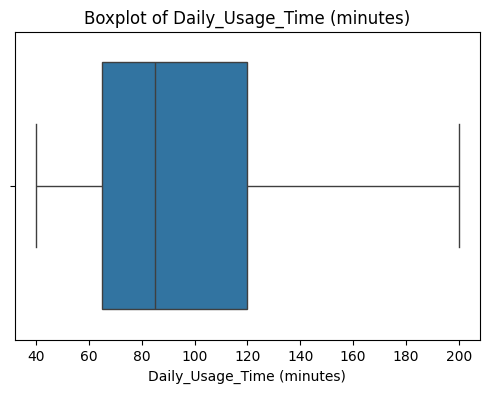

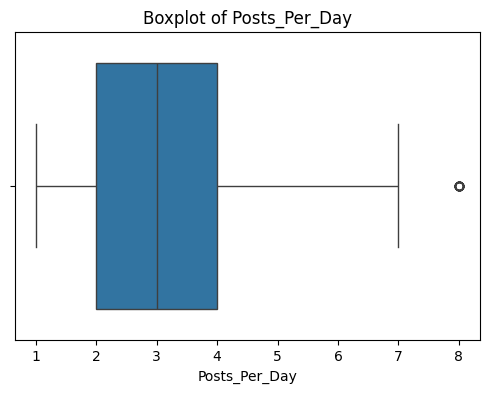

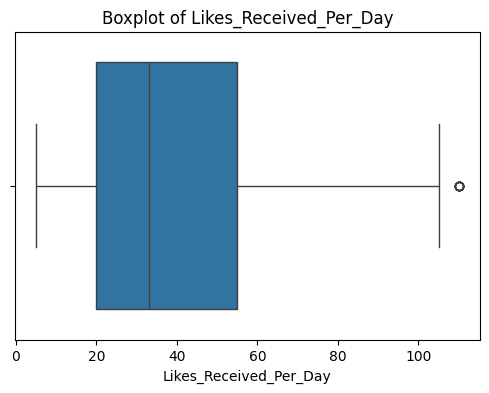

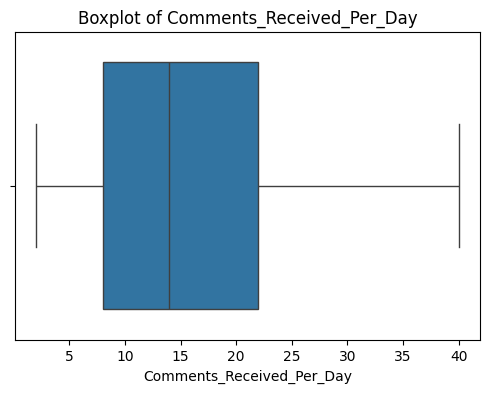

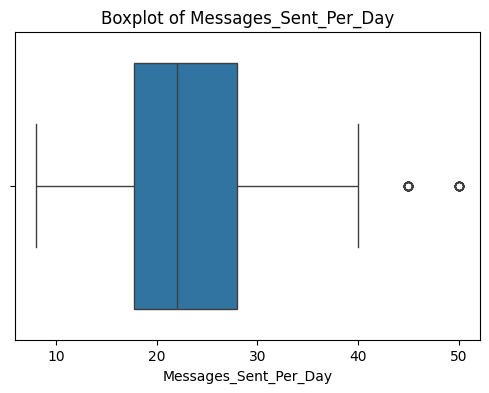

In [ ]:
# Boxplots and Outlier Detection
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()


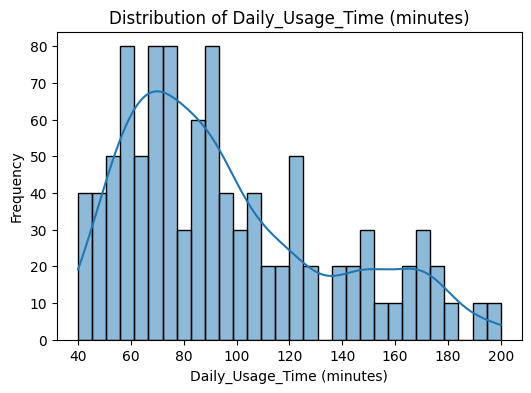

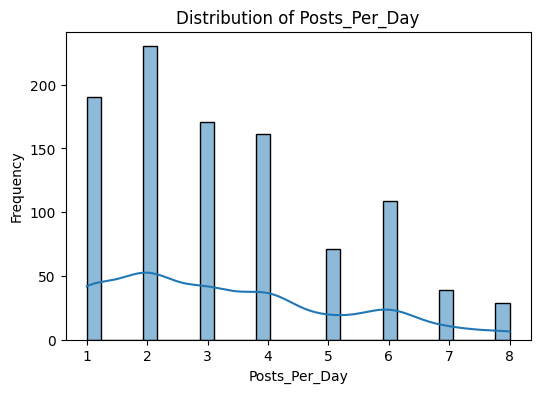

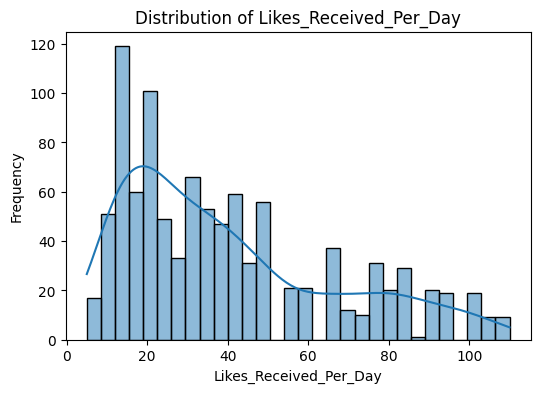

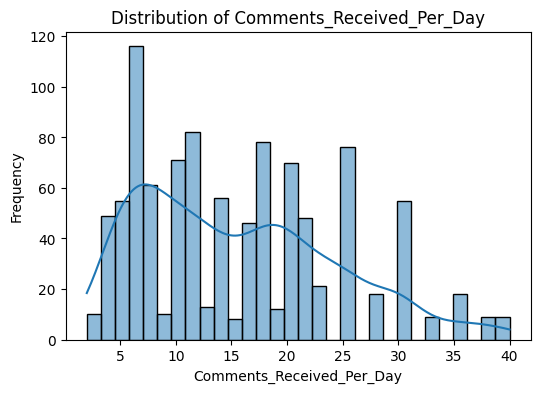

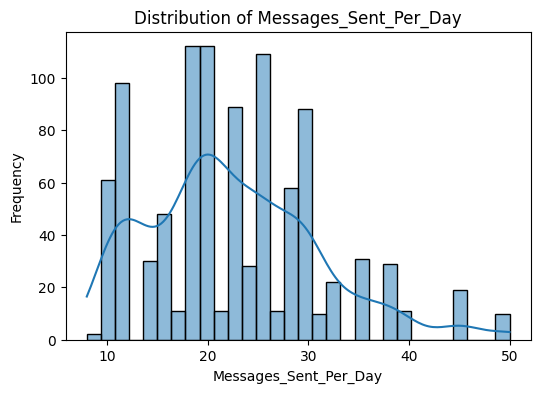

In [ ]:
# Histograms for Numeric Distributions
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


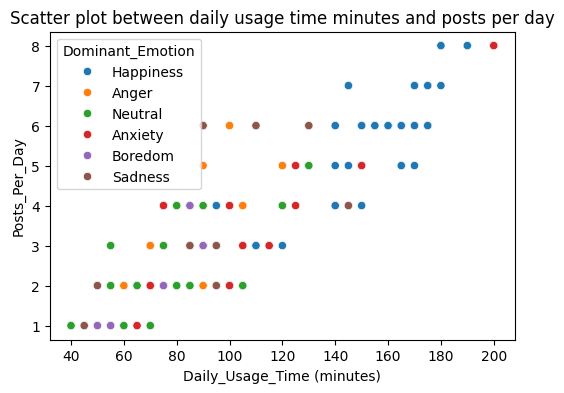

In [ ]:
# Scatter Plot (Pairwise Comparison)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Daily_Usage_Time (minutes)', y='Posts_Per_Day', hue='Dominant_Emotion')
plt.title('Scatter plot between daily usage time minutes and posts per day')
plt.show()


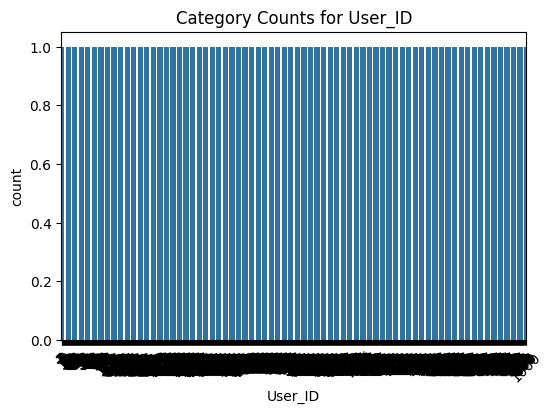

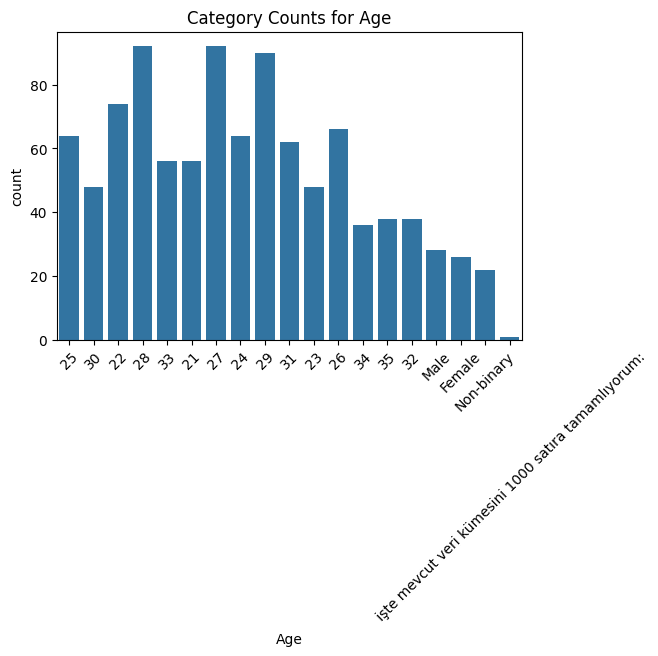

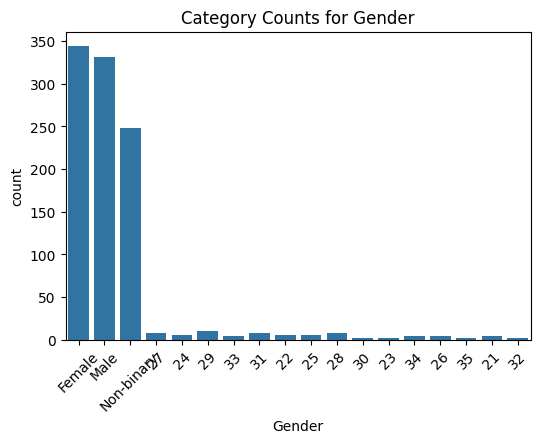

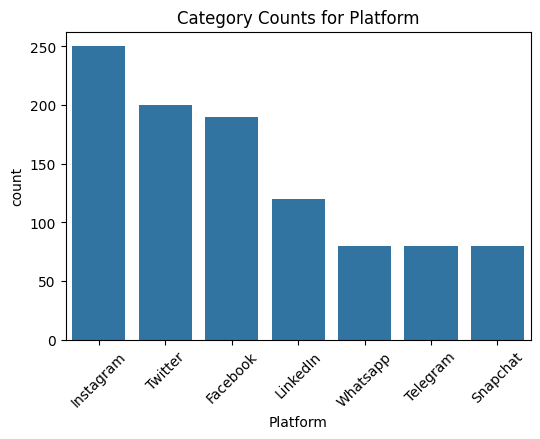

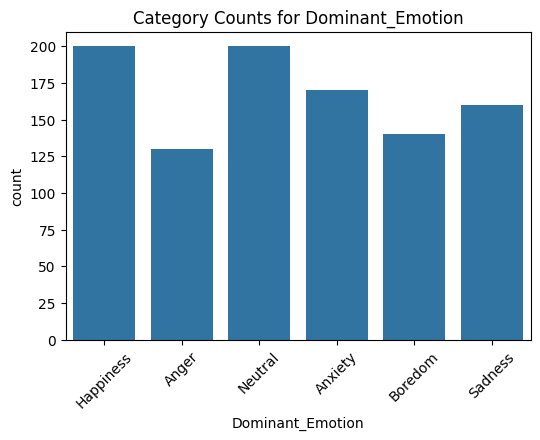

In [ ]:
# Bar Plots for Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Category Counts for {col}')
    plt.xticks(rotation=45)
    plt.show()


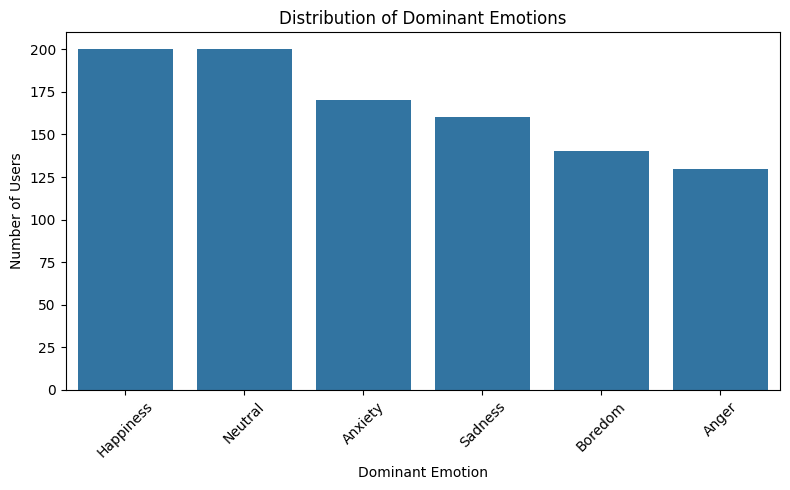

In [ ]:
# Class Label Distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Dominant_Emotion', order=df['Dominant_Emotion'].value_counts().index)
plt.title('Distribution of Dominant Emotions')
plt.xlabel('Dominant Emotion')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


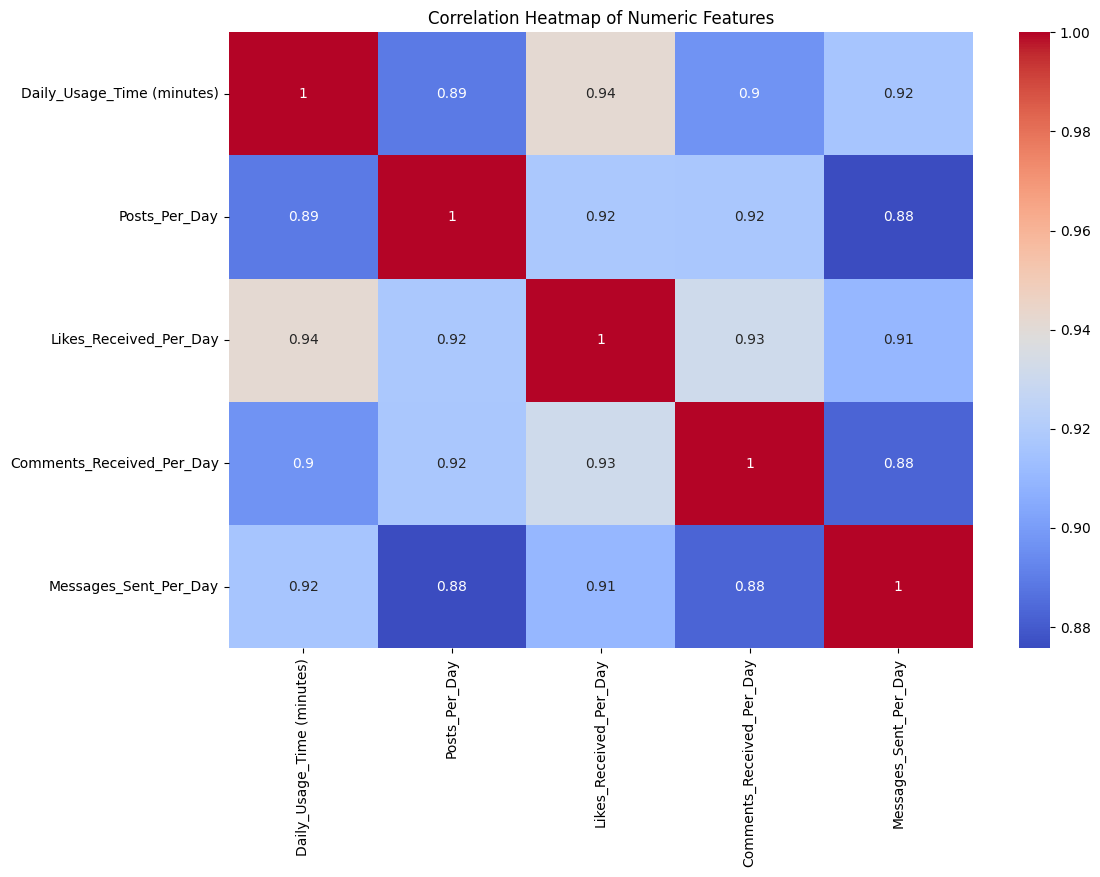

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


### **Part 2**: Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Handling Missing Values

We used mean to fill missing numeric values and mode for categorical columns (Gender, Platform, Dominant_Emotion).
This was done to avoid losing rows and keep the dataset complete for analysis









In [ ]:

# Load your raw dataset
df = pd.read_csv(url)

# Drop completely empty rows
df = df.dropna(how='all')

# Show the new shape
print("Shape after cleaning:", df.shape)
df.head()



Shape after cleaning: (1001, 10)


,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
1,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
3,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
5,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
7,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
9,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom


In [ ]:
# Numeric columns
numeric_cols = [
    "Age",
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

# Convert to numeric (convert text or invalid values into NaN)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Fill missing numeric values with column mean
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print(" Numeric columns cleaned and missing values filled.")

 Numeric columns cleaned and missing values filled.



## Encoding Categorical Data

We applied Label Encoding on categorical attributes (Gender, Platform) to convert text values into numeric form that machine learning algorithms can process (except class coulmn)


In [ ]:
# Encode only non-target categorical columns
label_cols = ["Gender", "Platform",]

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Categorical columns encoded (Class column left unchanged).")

Categorical columns encoded (Class column left unchanged).



## Normalization

We used Min–Max Normalization to scale all numeric attributes between 0 and 1, ensuring that each feature contributes equally to the model


In [ ]:
# Apply Min-Max normalization to numeric columns
# Keep Age as it is
numeric_to_scale = [
    "Daily_Usage_Time (minutes)",
    "Posts_Per_Day",
    "Likes_Received_Per_Day",
    "Comments_Received_Per_Day",
    "Messages_Sent_Per_Day"
]

scaler = MinMaxScaler()
df[numeric_to_scale] = scaler.fit_transform(df[numeric_to_scale])

print("Numeric columns normalized (except Age).")

Numeric columns normalized (except Age).


## Discretization (Age)

We transformed the Age column into five categorical ranges (Teen, Young Adult, Adult, Middle Age, Senior)
to better represent behavioral differences among age groups

In [ ]:
# Define bins (ranges) and labels
bins = [0, 18, 30, 45, 60, 100]
labels = ['Teen', 'Young Adult', 'Adult', 'Middle Age', 'Senior']

# Replace Age column with categorical ranges
df['Age'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
print(" Age column replaced with categorical ranges.")

 Age column replaced with categorical ranges.


## Remove User_ID column (not needed for mining)
Why: The User_ID column serves only as an identifier and has no analytical meaning.

Effect: Removing it prevents unnecessary noise and improves dataset quality

In [ ]:
if "User_ID" in df.columns:
    df = df.drop(columns=["User_ID"])
    print("'User_ID' column removed.")

'User_ID' column removed.


## Save the final cleaned dataset
Technique: Data Export
Why: After completing all preprocessing steps, the clean and ready dataset was saved as Preprocessed_dataset.csv.

Effect: The preprocessed file is now ready for use in the next phase (data analysis or data mining)

In [ ]:

df.to_csv("Preprocessed_dataset.csv", index=False)
print(" File saved as Preprocessed_dataset.csv")

 File saved as Preprocessed_dataset.csv


In Phase 2, the dataset was updated and preprocessed based on the feedback from Phase 1.
The following changes were made to improve data quality and prepare it for analysis:

**Removed Empty Rows:**
All completely empty rows were deleted to clean the dataset and ensure valid entries only.

**Handled Missing Values:**
Mean imputation was applied to numeric columns to prevent gaps in the data.

**Standardized Data Types:**
Non-numeric values in numeric columns were converted properly using the to_numeric() function with error handling.

**Encoded Categorical Columns:**
The columns Gender, Platform, and Dominant_Emotion were converted from text to numeric form using Label Encoding.

**Normalized Numeric Data:**
Continuous columns such as Daily Usage Time and Posts Per Day were scaled to a range between 0 and 1 using Min–Max Normalization.

**Transformed Age Column:**
The Age column was discretized into categories (Teen, Young Adult, Adult, Middle Age, Senior) to simplify analysis and enhance interpretability.

**Removed Irrelevant Attribute:**
The User_ID column was deleted as it only serves as an identifier and has no analytical value.

**Saved as a New File:**
The updated dataset was saved as Preprocessed_dataset.csv for use in the next phase (Phase 3).

Overall, these modifications improved the dataset’s consistency, interpretability, and readiness for data mining tasks.


# Summarize Attributes and there types after pre-processing

In [ ]:
# 📊 Enhanced Column Summary Report (fixed for category type)
import pandas as pd
import numpy as np

print("🔍 Dataset Columns Summary\n")

for col in df.columns:
    dtype = df[col].dtype

    print(f"📌 Column Name: {col}")
    print(f"   ▪️ Data Type: {dtype}")

    # عدد القيم الفارغة
    missing = df[col].isna().sum()
    print(f"   ▪️ Missing Values: {missing}")

    # إذا العمود رقمي (حتى لو كان نوعه float أو int أو numeric category)
    if pd.api.types.is_numeric_dtype(df[col]):
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"   ▪️ Range: {col_min} → {col_max}")
    else:
        unique_vals = df[col].unique()
        unique_count = len(unique_vals)
        if unique_count <= 10:
            print(f"   ▪️ Unique Values: {list(unique_vals)}")
        else:
            print(f"   ▪️ Unique Values Count: {unique_count}")

    print("-" * 60)


🔍 Dataset Columns Summary

📌 Column Name: Age
   ▪️ Data Type: category
   ▪️ Missing Values: 0
   ▪️ Unique Values: ['Young Adult', 'Adult']
------------------------------------------------------------
📌 Column Name: Gender
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 18
------------------------------------------------------------
📌 Column Name: Platform
   ▪️ Data Type: int64
   ▪️ Missing Values: 0
   ▪️ Range: 0 → 7
------------------------------------------------------------
📌 Column Name: Daily_Usage_Time (minutes)
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Posts_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
------------------------------------------------------------
📌 Column Name: Likes_Received_Per_Day
   ▪️ Data Type: float64
   ▪️ Missing Values: 0
   ▪️ Range: 0.0 → 1.0
-------------------------------------------------

# Phase 2 – Data Mining
ClusteringIn this phase, we will apply data mining techniques to the preprocessed data from the previous phase.
 1. Classification: We will use Decision Trees to classify users into emotional categories based on their social media usage. What we aim to achieve from this process is to determine the dominant emotion for each user, such as Happiness, Sadness, or Anger, based on their usage patterns.
 2. Clustering: We will apply K-means clustering to group users based on their activity on social media platforms, such as those with high activity, high engagement, or low engagement. The goal here is to understand user segmentation and explore how their digital behavior affects their emotional states.

## 1) Load the Preprocessed Dataset

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df = pd.read_csv('Preprocessed_dataset(3).csv')

df.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238,Happiness
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810,Anger
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714,Neutral
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000,Anxiety
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619,Boredom


## Select the Features for Clustering


In [ ]:
df_cluster = df.drop(['Dominant_Emotion'], axis=1)

df_cluster.head()


,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day
0,0.285714,15,1,0.50000,0.285714,0.380952,0.210526,0.095238
1,0.642857,16,5,0.31250,0.571429,0.142857,0.605263,0.523810
2,0.071429,17,0,0.12500,0.142857,0.095238,0.078947,0.285714
3,0.500000,15,1,1.00000,1.000000,0.904762,0.736842,1.000000
4,0.857143,16,2,0.03125,0.000000,0.000000,0.000000,0.047619


## Elbow Method

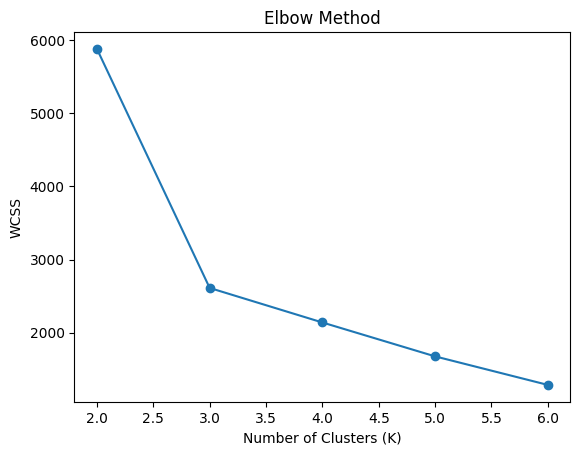

In [ ]:
k_values = [2, 3, 4, 5, 6]
wcss = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()


## حساب Silhouette Score لكل K

In [ ]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)
    sil_score = silhouette_score(df_cluster, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} → Silhouette Score = {sil_score:.4f}")


K = 2 → Silhouette Score = 0.7183
K = 3 → Silhouette Score = 0.5526
K = 4 → Silhouette Score = 0.4741
K = 5 → Silhouette Score = 0.4609
K = 6 → Silhouette Score = 0.5070


## تطبيق K-Means على أفضل 3 قيم K

In [ ]:
best_k_values = [2, 3, 4]   # غيّريها حسب النتائج عندك

cluster_results = {}

for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    sil_score = silhouette_score(df_cluster, labels)
    wcss_k = kmeans.inertia_

    cluster_results[k] = {
        'labels': labels,
        'silhouette': sil_score,
        'wcss': wcss_k
    }

    print(f"===== K = {k} =====")
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"WCSS: {wcss_k:.2f}")


===== K = 2 =====
Silhouette Score: 0.7183
WCSS: 5877.26
===== K = 3 =====
Silhouette Score: 0.5526
WCSS: 2612.23
===== K = 4 =====
Silhouette Score: 0.4741
WCSS: 2140.65


## رسم الكلسترز

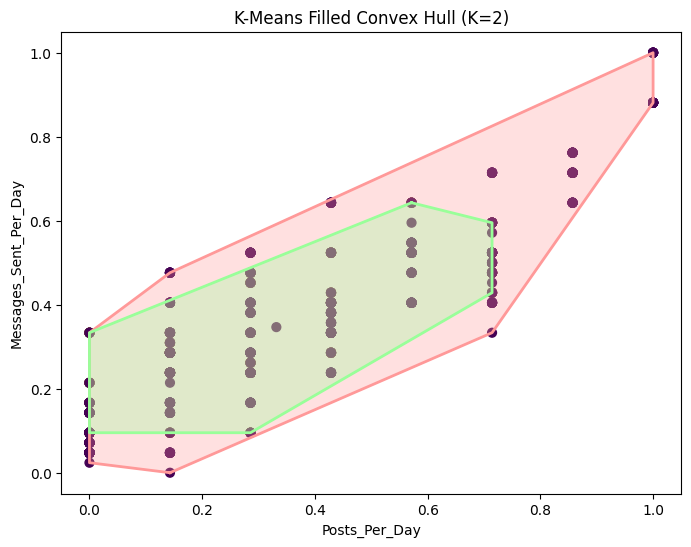

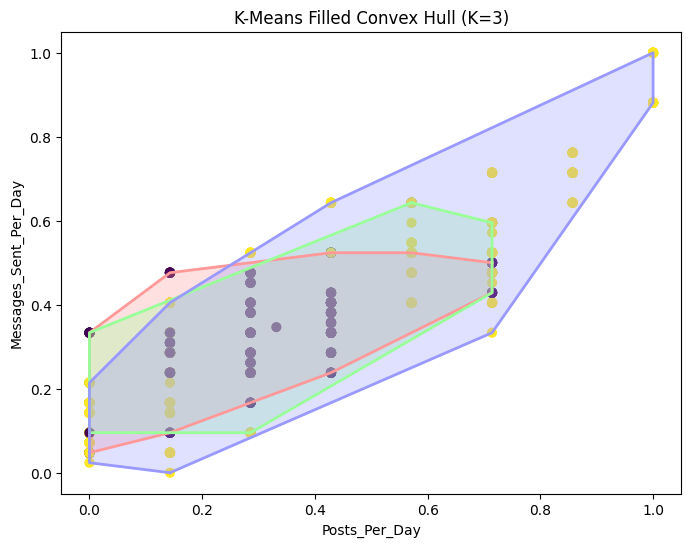

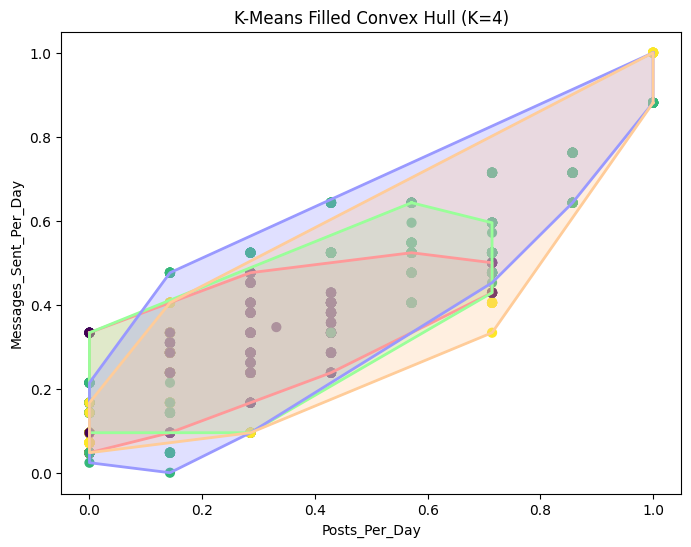

In [ ]:
from scipy.spatial import ConvexHull
import numpy as np

feature_x = 'Posts_Per_Day'
feature_y = 'Messages_Sent_Per_Day'

# ألوان التعبئة لكل Cluster
fill_colors = ['#ff9999', '#99ff99', '#9999ff', '#ffcc99', '#cc99ff']

for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster)

    plt.figure(figsize=(8,6))

    # رسم النقاط
    plt.scatter(df_cluster[feature_x], df_cluster[feature_y],
                c=labels, cmap='viridis', s=40)

    # رسم Convex Hull لكل Cluster
    for cluster_id in np.unique(labels):
        cluster_points = df_cluster[labels == cluster_id][[feature_x, feature_y]].values

        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            hull_points = cluster_points[hull.vertices]
            hull_points = np.concatenate([hull_points, hull_points[:1]])

            # تعبئة شكل الـ Hull
            plt.fill(hull_points[:,0], hull_points[:,1],
                     color=fill_colors[cluster_id],
                     alpha=0.3)

            # رسم حدود الـ Hull
            plt.plot(hull_points[:,0], hull_points[:,1],
                     color=fill_colors[cluster_id],
                     linewidth=2)

    plt.xlabel(feature_x)
    plt.ylabel(feature_y)
    plt.title(f"K-Means Filled Convex Hull (K={k})")
    plt.show()


هنا رسم الكلستر قبل لا نحدد قيمة الK
تحت بعد ما اخترت ان ال K=3اعتمادا على elbow

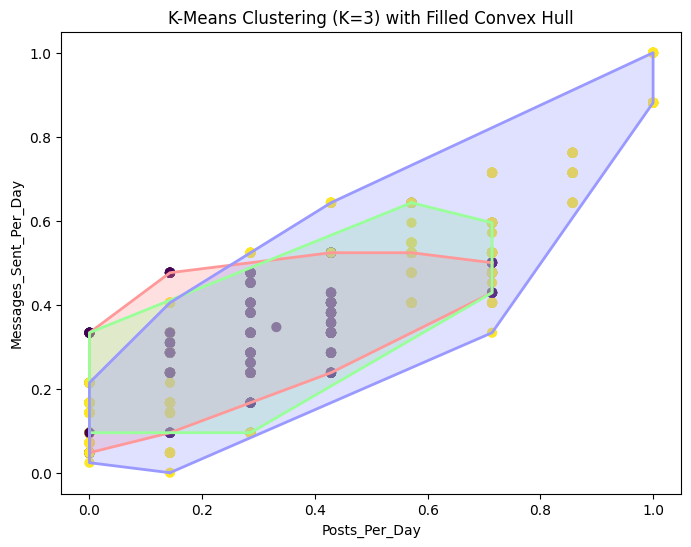

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

# الميزتين اللي بنرسم عليها
feature_x = 'Posts_Per_Day'
feature_y = 'Messages_Sent_Per_Day'

# تشغيل K-Means على 3 كلاستر
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_cluster)

plt.figure(figsize=(8,6))

# رسم النقاط
plt.scatter(df_cluster[feature_x], df_cluster[feature_y],
            c=labels, cmap='viridis', s=40)

# رسم Convex Hull ممتلئ لكل Cluster
colors = ['#ff9999', '#99ff99', '#9999ff']  # ألوان تعبئة ناعمة

for cluster_id in np.unique(labels):
    cluster_points = df_cluster[labels == cluster_id][[feature_x, feature_y]].values

    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]

        # نغلق الشكل
        hull_points = np.concatenate([hull_points, hull_points[:1]])

        # تعبئة المنطقة (Filled polygon)
        plt.fill(hull_points[:,0], hull_points[:,1],
                 alpha=0.3, color=colors[cluster_id])

        # خط الحدود
        plt.plot(hull_points[:,0], hull_points[:,1],
                 color=colors[cluster_id], linewidth=2)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title("K-Means Clustering (K=3) with Filled Convex Hull")
plt.show()
